# 12 - Centrality in the rail network and socioeconomic profile

The rail graph built in notebook 11 tells us *where* Israel's rail network is structurally fragile. This notebook asks the follow-up question: **does that fragility, and the service volume that goes with it, line up with the socioeconomic profile of the neighborhoods where the stations sit?** We attach each rail station to the CBS statistical-area socioeconomic layer for 2021, compare families of centrality metrics across socioeconomic groups and across administrative districts, classify each station into a structural archetype, and test the socioeconomic relationships formally.

**Research question.** Are high-centrality, high-service-volume, or structurally critical rail stations systematically located in richer or poorer statistical areas?

**Input**
- `outputs/nb/11_*/tables/rail_station_metrics.csv` - station-level centrality in the rail network (67 stations).
- `outputs/nb/11_*/tables/single_station_damage.csv` - stations disconnected by a single modeled failure.
- `stops_with_socioeconomic.csv` - the project's spatial join between stations and CBS statistical areas
  (`socio_cluster`, `socio_index_value`, `region`, `metro`, the matching method and distance).
  Both inputs are located automatically; see the "Locating the inputs" section.

**Output** (all under `outputs/nb/12_rail_socioeconomic/`)
- `tables/rail_station_archetypes.csv` - the full merged table, including percentiles, both composite scores
  and the archetype label.
- `tables/rail_centrality_spearman.csv` - a metric-vs-metric redundancy matrix.
- `tables/composite_score_comparison.csv` - the original (legacy) composite ranking vs the family-balanced ranking.
- `tables/rail_socioeconomic_correlations.csv` - 24 Spearman tests **including** a correction for multiple comparisons.
- `tables/rail_socioeconomic_group_summary.csv`, `tables/rail_regional_summary.csv`.
- `figures/centrality_profile_heatmap.png`, `figures/service_vs_structural_damage.png`,
  `figures/socioeconomic_centrality_profiles.png`, `figures/regional_rail_profile.png`.

**Four things this notebook fixes or exposes explicitly relative to the earlier script version**
1. *Non-comparable percentile scales in the profile heatmap.* The old figure placed five centrality percentiles
   (ranked across all 67 stations) next to a damage percentile that was ranked only among the ~14 stations whose
   removal actually breaks the graph, while the color bar declared "percentile among 67 rail stations". Here the
   damage column is drawn on **its own separate axis with its own color bar in raw units**, and both definitions
   of the damage percentile are exported side by side under explicit names.
2. *A redundant composite score.* Averaging five percentiles counts service volume three times
   (`weighted_degree` vs `scheduled_stop_calls`, Spearman rho = 0.94; `weighted_degree` vs
   `pagerank` = 0.86). We keep the original score for continuity, but make the **family-balanced** composite the
   leading number and show how the two rankings differ.
3. *24 Spearman tests with no correction.* We add Benjamini-Hochberg and Holm corrections and report the result
   honestly: **nothing is significant, not even before correction.** That negative result is the finding, not a
   failure of the analysis.
4. *Tiny district groups.* The district columns are marked with n, because Jerusalem has n = 3 stations and the
   South has n = 7; these averages aren't stable quantities.

## Setting up the environment

This cell makes the notebook runnable both from a local clone of the repository and from a fresh Google Colab session: it installs only the packages that are actually missing, locates the repository root (or clones it in Colab), and creates the shared `outputs/nb` folder that every notebook in this series writes to. It's safe to run again.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## Libraries, constants, and the stage output folder

Everything described below runs on a 67-row table, so there's no computationally expensive step in this notebook - a full run takes less than a second and needs no sampling or approximation. The constants are gathered here so the analysis can be retuned in one place:

- `TOP_QUINTILE = 0.80` - the percentile threshold above which a station counts as "high" on a given metric; it drives both the archetype rules and the `top_quintile_centrality_count` count.
- `PROFILE_TOP_N = 16` - the number of stations shown in the multi-metric heatmap.

`CENTRALITY_FAMILIES` is the grouping we use to correct the redundancy in the composite score: `degree`, `weighted_degree` and `pagerank` all measure, roughly, "how much service passes through here", so they're averaged *within* a family before the families are averaged against each other.

We also create a stage folder dedicated to this notebook. Nothing is ever written to `outputs/tables`, `outputs/figures` or `outputs/rail`.

In [2]:
_ensure("pandas", "numpy", "matplotlib", "seaborn", "scipy")

from itertools import cycle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid", font_scale=1.0)  # must run BEFORE the Hebrew font patch

STAGE = OUT / "12_rail_socioeconomic"
(STAGE / "tables").mkdir(parents=True, exist_ok=True)
(STAGE / "figures").mkdir(parents=True, exist_ok=True)

# ---- tunable constants -------------------------------------------------------
TOP_QUINTILE = 0.80      # "high" on a metric = top 20% of the 67 rail stations
PROFILE_TOP_N = 16       # rows in the multi-metric profile heatmap
FIG_DPI = 200

CENTRALITY_METRICS = [
    "degree",
    "weighted_degree",
    "pagerank",
    "betweenness",
    "harmonic",
]
DAMAGE_METRIC = "stations_outside_largest_component"
PROFILE_METRICS = CENTRALITY_METRICS + [DAMAGE_METRIC]
PROFILE_LABELS = {
    "degree": "Degree",
    "weighted_degree": "Service volume",
    "pagerank": "PageRank",
    "betweenness": "Betweenness",
    "harmonic": "Harmonic",
    DAMAGE_METRIC: "Single-outage damage",
}

# Grouping used by the family-balanced composite score (fix #2).
CENTRALITY_FAMILIES = {
    "Service volume": ["degree", "weighted_degree", "pagerank"],
    "Brokerage": ["betweenness"],
    "Global accessibility": ["harmonic"],
}

print("Stage folder:", STAGE)

Stage folder: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\12_rail_socioeconomic


## Hebrew labels in matplotlib

Every station name, district name and locality name in the GTFS feed is in Hebrew. matplotlib draws characters in logical order (storage order) and doesn't apply the Unicode bidirectional algorithm, so Hebrew comes out reversed. The fix below wraps `Text.set_text` once, so that *every* string we pass to matplotlib - axis labels, annotations and titles - is converted automatically to display order.

Because the fix is global, the rest of the notebook passes matplotlib **raw** Hebrew strings and doesn't call `fix_he` manually; an extra manual call would reverse the text twice.

In [3]:
# Stop names are Hebrew. Matplotlib does not apply the Unicode bidi algorithm, so
# Hebrew labels render reversed. Patch it once, before drawing any figure.
_ensure("python-bidi")
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

# Fail loudly if python-bidi is not actually reordering Hebrew. A broken or no-op
# build makes get_display a pass-through, silently rendering every Hebrew label
# reversed. Assert the reordering works so the notebook errors here instead of
# producing backwards figures.
if get_display("אבג") != "גבא":
    raise RuntimeError(
        "python-bidi is not reordering Hebrew (get_display is a no-op); Hebrew "
        "figure labels would render reversed. Reinstall a working build:\n"
        "    pip install -U --force-reinstall 'python-bidi>=0.6.7'"
    )

_HEBREW_RE = re.compile(r"[\u0590-\u05FF]")

def fix_he(text):
    """Return display-ordered text. Non-Hebrew is returned untouched."""
    if not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

## Locating the inputs

This notebook is a *consumer* stage: it doesn't compute a graph of its own. It needs two things.

**1. The rail results from notebook 11.** We first look under `outputs/nb/11_*/tables/`. If that stage wasn't run in the current session, we fall back to the fixed report tables under `outputs/rail/tables` (read-only - we never write there), and say so explicitly. If neither exists, we raise a clear error telling you to run notebook 11.

**2. The socioeconomic join.** `stops_with_socioeconomic.csv` maps every GTFS station to a CBS 2021 statistical area (cluster 1-10, index value, locality, population) plus an administrative district and metro label. Producing it requires `geopandas` and a live download of the CBS ArcGIS layer, so it's a **fixed data asset in the repository** rather than something recomputed here. We first look for it in every notebook stage folder, then fall back to the copy managed under notebook 09, which downloads the CBS layer live and writes it to its own stage folder. This is a data dependency, not a code dependency: no module from that folder is imported.

In [4]:
RAIL_TABLE_NAMES = ["rail_station_metrics.csv", "single_station_damage.csv"]


def _find_stage_dir(prefix):
    """Return the first outputs/nb folder whose name starts with `prefix`."""
    matches = sorted(p for p in OUT.glob(prefix + "*") if p.is_dir())
    return matches[0] if matches else None


def resolve_rail_tables():
    stage_11 = _find_stage_dir("11_")
    if stage_11 is not None:
        tables = stage_11 / "tables"
        if all((tables / name).exists() for name in RAIL_TABLE_NAMES):
            print("Rail metrics source: notebook 11 stage outputs ->", tables)
            return tables
    legacy = REPO / "outputs" / "rail" / "tables"
    if all((legacy / name).exists() for name in RAIL_TABLE_NAMES):
        print("Rail metrics source: committed report tables ->", legacy)
        print("  (notebook 11 stage output not found; these are read-only and never modified)")
        return legacy
    raise FileNotFoundError(
        f"Missing {RAIL_TABLE_NAMES} in {OUT}/11_*/tables and in {legacy} - "
        "run notebook 11 (rail network analysis) first."
    )


def resolve_socioeconomic_csv():
    """Locate the CBS stop-to-statistical-area join produced by notebook 09."""
    for candidate in sorted(OUT.glob("*/tables/stops_with_socioeconomic.csv")):
        print("Socioeconomic source: notebook stage output ->", candidate)
        return candidate
    raise FileNotFoundError(
        f"stops_with_socioeconomic.csv not found under {OUT}/*/tables/. "
        "It is produced by notebook 09 (socioeconomic equity), which downloads the "
        "CBS 2021 statistical-area layer and joins every GTFS stop to it. "
        "Run 09_socioeconomic_equity.ipynb first."
    )


RAIL_TABLES = resolve_rail_tables()
SOCIO_CSV = resolve_socioeconomic_csv()

metrics = pd.read_csv(
    RAIL_TABLES / "rail_station_metrics.csv", dtype={"stop_id": str}, encoding="utf-8-sig"
)
damage = pd.read_csv(
    RAIL_TABLES / "single_station_damage.csv", dtype={"stop_id": str}, encoding="utf-8-sig"
)[["stop_id", DAMAGE_METRIC, "components"]]
socioeconomic = pd.read_csv(
    SOCIO_CSV, dtype={"stop_id": str}, encoding="utf-8-sig", low_memory=False
)

print(f"\nrail stations: {len(metrics)} | damage rows: {len(damage)} | "
      f"stops in socioeconomic join: {len(socioeconomic):,}")
metrics.head(3)

Rail metrics source: notebook 11 stage outputs -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\11_rail_network_analysis\tables
Socioeconomic source: notebook stage output -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\09_socioeconomic_equity\tables\stops_with_socioeconomic.csv

rail stations: 67 | damage rows: 67 | stops in socioeconomic join: 30,463


,stop_id,stop_code,stop_name,stop_lat,stop_lon,scheduled_stop_calls,degree,weighted_degree,in_degree,out_degree,pagerank,betweenness,harmonic,is_articulation_point,community_id
0,37292,17104,תל אביב ההגנה,32.053978,34.784839,752,8,1493,8,8,0.039443,0.537840,0.363366,True,5
1,37362,17034,הרצליה,32.163558,34.817406,599,8,846,8,8,0.022429,0.514608,0.363961,False,8
2,37358,17038,תל אביב מרכז,32.083715,34.798247,815,4,1543,4,4,0.031372,0.508625,0.330339,True,5


## Building the analysis table

We merge the three sources on `stop_id` and derive the columns the rest of the notebook uses.

- **`socio_group`** splits the CBS cluster into three readable bands (the observed range is 2-9, so there are no empty bands): low = 2-4, medium = 5-7, high = 8-9.
- **Centrality percentiles** rank each of the five metrics across *all* stations using `method="average"`, so a tie (very common for `degree`) gets the shared middle rank.
- **Damage percentiles - the fix.** The original code produced one column that was zero for stations that don't break the graph, and a percentile *among the breaking minority* for the rest. That's a reasonable display choice, but it's **not** a percentile among 67, which is exactly what the old heatmap's color bar declared. We now compute both, under names that state what they are:
  - `damage_percentile_among_67` - ranked across all stations, directly comparable to the five centrality percentiles (every non-breaking station lands on the same shared middle rank);
  - `damage_percentile_among_damaging` - the original definition, ranked only among the stations whose removal actually disconnects something, with the zeros forced to 0.
  The heatmap that follows avoids the ambiguity entirely by drawing damage in raw units on its own separate scale.

If any rail station fails to get a socioeconomic assignment, we stop with a hard error rather than quietly analyzing a biased subset.

In [5]:
SOCIO_COLUMNS = [
    "stop_id",
    "socio_locality",
    "socio_cluster",
    "socio_index_value",
    "socio_population",
    "socio_join_method",
    "socio_join_distance_m",
    "region",
    "metro",
]


def build_analysis_frame(metrics, damage, socioeconomic):
    frame = metrics.merge(damage, on="stop_id", how="left").merge(
        socioeconomic[SOCIO_COLUMNS], on="stop_id", how="left"
    )
    if frame["socio_cluster"].isna().any():
        missing = frame.loc[frame["socio_cluster"].isna(), "stop_name"].tolist()
        raise ValueError(f"Rail stations missing socioeconomic assignments: {missing}")

    # Booleans can survive a CSV round-trip as strings; normalise defensively.
    frame["is_articulation_point"] = (
        frame["is_articulation_point"].astype(str).str.strip().str.lower().isin(["true", "1"])
    )
    frame[DAMAGE_METRIC] = frame[DAMAGE_METRIC].fillna(0).astype(int)
    frame["components"] = frame["components"].fillna(1).astype(int)

    frame["socio_group"] = pd.cut(
        frame["socio_cluster"],
        bins=[0, 4, 7, 10],
        labels=["Lower (clusters 2-4)", "Middle (clusters 5-7)", "Higher (clusters 8-9)"],
    )

    for metric in CENTRALITY_METRICS:
        frame[f"{metric}_percentile"] = frame[metric].rank(method="average", pct=True)

    # (fix 1) Two explicitly named damage scales instead of one mislabelled one.
    frame["damage_percentile_among_67"] = frame[DAMAGE_METRIC].rank(
        method="average", pct=True
    )
    frame["damage_percentile_among_damaging"] = 0.0
    damaging = frame[DAMAGE_METRIC] > 0
    frame.loc[damaging, "damage_percentile_among_damaging"] = frame.loc[
        damaging, DAMAGE_METRIC
    ].rank(method="average", pct=True)

    frame["top_quintile_centrality_count"] = sum(
        frame[f"{metric}_percentile"].ge(TOP_QUINTILE).astype(int)
        for metric in CENTRALITY_METRICS
    )
    return frame


frame = build_analysis_frame(metrics, damage, socioeconomic)

n_damaging = int((frame[DAMAGE_METRIC] > 0).sum())
print(f"stations: {len(frame)}")
print(f"socioeconomic join: {(frame.socio_join_method == 'within').sum()} within-polygon, "
      f"{(frame.socio_join_method == 'nearest').sum()} nearest-polygon")
print(f"CBS cluster range: {frame.socio_cluster.min():.0f}-{frame.socio_cluster.max():.0f}")
print(f"stations whose single removal separates others: {n_damaging} of {len(frame)}")
print("\nWhy the two damage scales differ (a non-fragmenting station):")
cols = ["stop_name", DAMAGE_METRIC, "damage_percentile_among_67", "damage_percentile_among_damaging"]
print(frame.sort_values(DAMAGE_METRIC, ascending=False)[cols].head(3).to_string(index=False))
print(frame.loc[frame[DAMAGE_METRIC] == 0, cols].head(2).to_string(index=False))
frame["socio_group"].value_counts().sort_index()

stations: 67


socioeconomic join: 44 within-polygon, 23 nearest-polygon
CBS cluster range: 2-9
stations whose single removal separates others: 14 of 67

Why the two damage scales differ (a non-fragmenting station):
    stop_name  stations_outside_largest_component  damage_percentile_among_67  damage_percentile_among_damaging
 תל אביב מרכז                                  33                    1.000000                          1.000000
תל אביב ההגנה                                  27                    0.985075                          0.928571
    חוף הכרמל                                  15                    0.970149                          0.857143
stop_name  stations_outside_largest_component  damage_percentile_among_67  damage_percentile_among_damaging
   הרצליה                                   0                    0.402985                               0.0
    השלום                                   0                    0.402985                               0.0


socio_group
Lower (clusters 2-4)     18
Middle (clusters 5-7)    28
Higher (clusters 8-9)    21
Name: count, dtype: int64

## How redundant are the five centrality metrics? (fix 2)

Before we combine metrics into a single number, it's worth checking whether they measure different things. The Spearman matrix below shows that mostly they don't: `weighted_degree` and `scheduled_stop_calls` correlate at rho ~ 0.94 (they're almost the same quantity - a station's weighted degree in a service graph *is* its traffic load), and `pagerank` sits at ~0.86 against `weighted_degree`. So the old `composite_centrality_score`, a plain average of five percentiles, effectively gave service volume three votes out of five, while brokerage (betweenness) and reach each got one vote.

So we compute two scores and keep both in the exported table:

- `composite_centrality_score_legacy` - the original plain average of five percentiles (kept so the earlier report figures stay reproducible);
- `composite_centrality_score_balanced` - averaged *within* each family in `CENTRALITY_FAMILIES` first, then averaged across the three families, so volume / brokerage / reach get a 1:1:1 weight. This is the score the rest of the notebook ranks by.

The cell prints how much the two rankings actually differ, so the choice is auditable and not just asserted.

In [6]:
redundancy = frame[PROFILE_METRICS + ["scheduled_stop_calls"]].corr(method="spearman")
print("Spearman redundancy matrix (rail metrics):")
print(redundancy.round(3).to_string())
print(
    "\nweighted_degree vs scheduled_stop_calls: rho = "
    f"{redundancy.loc['weighted_degree', 'scheduled_stop_calls']:.3f}"
)

percentile_columns = [f"{m}_percentile" for m in CENTRALITY_METRICS]
frame["composite_centrality_score_legacy"] = 100 * frame[percentile_columns].mean(axis=1)

family_scores = pd.DataFrame(
    {
        family: frame[[f"{m}_percentile" for m in members]].mean(axis=1)
        for family, members in CENTRALITY_FAMILIES.items()
    },
    index=frame.index,
)
frame["composite_centrality_score_balanced"] = 100 * family_scores.mean(axis=1)
# Canonical alias used by the ranking below.
frame["composite_centrality_score"] = frame["composite_centrality_score_balanced"]

composite_comparison = frame[["stop_id", "stop_name"]].copy()
composite_comparison["score_legacy"] = frame["composite_centrality_score_legacy"]
composite_comparison["score_balanced"] = frame["composite_centrality_score_balanced"]
composite_comparison["rank_legacy"] = (
    frame["composite_centrality_score_legacy"].rank(ascending=False, method="min").astype(int)
)
composite_comparison["rank_balanced"] = (
    frame["composite_centrality_score_balanced"].rank(ascending=False, method="min").astype(int)
)
composite_comparison["rank_shift"] = (
    composite_comparison["rank_legacy"] - composite_comparison["rank_balanced"]
)

rho_scores = spearmanr(
    composite_comparison["score_legacy"], composite_comparison["score_balanced"]
).statistic
print(f"\nLegacy vs family-balanced composite: Spearman rho = {rho_scores:.3f}")
print("Largest ranking movers (positive shift = the balanced score ranks the station higher):")
movers = composite_comparison.reindex(
    composite_comparison["rank_shift"].abs().sort_values(ascending=False).index
).head(8)
print(movers[["stop_name", "rank_legacy", "rank_balanced", "rank_shift"]].to_string(index=False))

Spearman redundancy matrix (rail metrics):
                                    degree  weighted_degree  pagerank  betweenness  harmonic  stations_outside_largest_component  scheduled_stop_calls
degree                               1.000            0.551     0.587        0.712     0.823                               0.465                 0.458
weighted_degree                      0.551            1.000     0.859        0.665     0.454                               0.380                 0.943
pagerank                             0.587            0.859     1.000        0.752     0.410                               0.517                 0.800
betweenness                          0.712            0.665     0.752        1.000     0.574                               0.568                 0.603
harmonic                             0.823            0.454     0.410        0.574     1.000                               0.366                 0.388
stations_outside_largest_component   0.465         

## Station archetypes

A single ranked score hides the fact that stations fail in different *ways*. The rule below (carried over unchanged from the original analysis) tags each station based on three binary signals:

- **high service** - top quintile on both `weighted_degree` and `pagerank`;
- **high brokerage** - top quintile on `betweenness`;
- **damaging cut** - the station is an articulation point *and* removing it actually disconnects at least one other station from the largest component.

The interesting cells are the combinations: a *critical high-service hub* is busy **and** a cut vertex (the worst case), a *redundant high-service hub* is busy but the network routes around it, and a *branch gateway* is a quiet station that nonetheless holds a whole branch connected to the network - exactly the kind of vulnerability a traffic-only ranking would miss.

In [7]:
def classify_station(row):
    high_service = (
        row["weighted_degree_percentile"] >= TOP_QUINTILE
        and row["pagerank_percentile"] >= TOP_QUINTILE
    )
    high_brokerage = row["betweenness_percentile"] >= TOP_QUINTILE
    damaging_cut = bool(row["is_articulation_point"]) and row[DAMAGE_METRIC] > 0
    if high_service and damaging_cut:
        return "critical high-service hub"
    if high_service and not damaging_cut:
        return "redundant high-service hub"
    if high_brokerage and damaging_cut:
        return "structural bottleneck"
    if high_brokerage:
        return "structural broker with alternatives"
    if damaging_cut:
        return "branch gateway"
    if row["harmonic_percentile"] >= TOP_QUINTILE:
        return "globally accessible connector"
    return "ordinary or peripheral station"


frame["station_archetype"] = frame.apply(classify_station, axis=1)
print(frame["station_archetype"].value_counts().to_string())
print()
print("Archetype by socioeconomic group (station counts):")
print(
    pd.crosstab(frame["station_archetype"], frame["socio_group"]).to_string()
)

station_archetype
ordinary or peripheral station         41
critical high-service hub               7
branch gateway                          6
redundant high-service hub              5
globally accessible connector           4
structural broker with alternatives     3
structural bottleneck                   1

Archetype by socioeconomic group (station counts):
socio_group                          Lower (clusters 2-4)  Middle (clusters 5-7)  Higher (clusters 8-9)
station_archetype                                                                                      
branch gateway                                          1                      4                      1
critical high-service hub                               3                      3                      1
globally accessible connector                           1                      2                      1
ordinary or peripheral station                         10                     17                     14
redundant hi

## Figure 1 - multi-metric profiles of the top stations (fix 1 applied)

We take the `PROFILE_TOP_N` stations with the largest number of top-quintile appearances (ties broken by the family-balanced composite) and show their percentile on each centrality metric.

The single-failure damage column is **not** shown as a percentile on the same color scale. The old figure did that, mixing a rank across 67 stations with a rank across the ~14 breaking stations, under a color bar that declared "percentile among 67". Here the left panel shows percentiles across all 67 stations (one color bar, one meaning), and the right panel shows the raw count of stations disconnected by removing that station, with its own color bar in units of stations. Reading across a row therefore compares like with like on the left, and gives an absolute magnitude on the right.

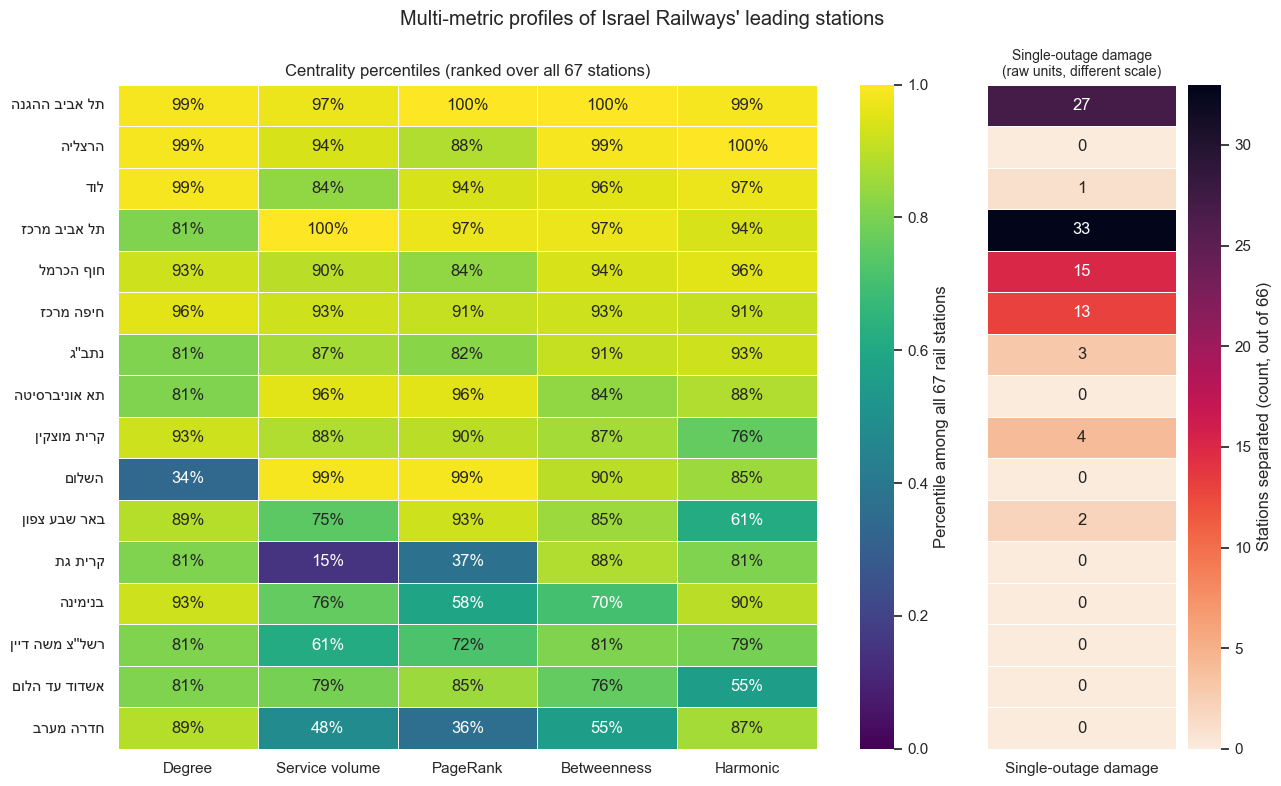

In [8]:
def plot_centrality_profiles(frame, path):
    ranking = frame.sort_values(
        ["top_quintile_centrality_count", "composite_centrality_score_balanced"],
        ascending=False,
    ).head(PROFILE_TOP_N)

    percentiles = ranking[[f"{m}_percentile" for m in CENTRALITY_METRICS]].copy()
    percentiles.columns = [PROFILE_LABELS[m] for m in CENTRALITY_METRICS]
    percentiles.index = list(ranking["stop_name"])

    damage_panel = ranking[[DAMAGE_METRIC]].copy()
    damage_panel.columns = [PROFILE_LABELS[DAMAGE_METRIC]]
    damage_panel.index = list(ranking["stop_name"])

    fig, axes = plt.subplots(
        1, 2, figsize=(13, 8), gridspec_kw={"width_ratios": [5, 1.35]}
    )
    sns.heatmap(
        percentiles,
        annot=True,
        fmt=".0%",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.4,
        cbar_kws={"label": "Percentile among all 67 rail stations"},
        ax=axes[0],
    )
    axes[0].set_title("Centrality percentiles (ranked over all 67 stations)")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")

    sns.heatmap(
        damage_panel,
        annot=True,
        fmt=".0f",
        cmap="rocket_r",
        vmin=0,
        vmax=int(frame[DAMAGE_METRIC].max()),
        linewidths=0.4,
        yticklabels=False,
        cbar_kws={"label": "Stations separated (count, out of 66)"},
        ax=axes[1],
    )
    axes[1].set_title("Single-outage damage\n(raw units, different scale)", fontsize=10)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")

    fig.suptitle("Multi-metric profiles of Israel Railways' leading stations")
    fig.tight_layout()
    fig.savefig(path, dpi=FIG_DPI)
    return fig


fig = plot_centrality_profiles(frame, STAGE / "figures" / "centrality_profile_heatmap.png")
plt.show()

## Figure 2 - operational load vs structural vulnerability

This scatter plot answers a planning question directly: are the stations whose failure would be most damaging the same stations that are busiest? The x-axis is the number of scheduled stop calls (log scale, because traffic spans orders of magnitude), the y-axis is the number of other stations that a single modeled failure disconnects from the largest component, bubble size is betweenness, and color is the local CBS socioeconomic cluster.

Points along the bottom are busy but redundant stations; points high on the left are the quiet branch gateways. We label every station that disconnects 3 or more stations, or that's in the top 8% of traffic. (A small robustness fix relative to the original: the label offsets are rotated cyclically instead of being pinned to a fixed list of 8, which quietly dropped labels when more than eight stations met the condition.)

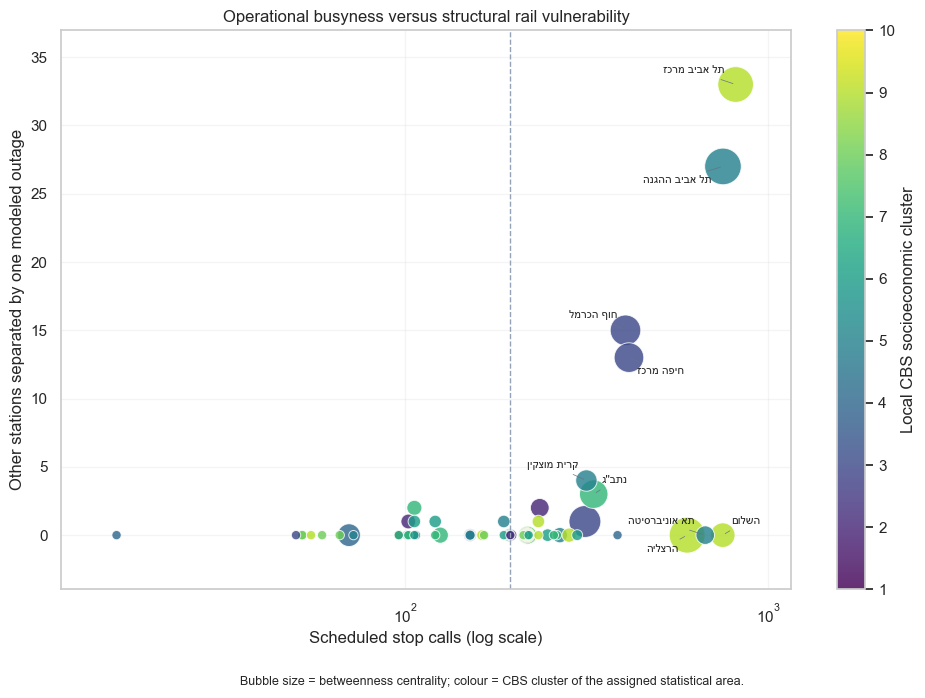

In [9]:
def plot_service_vs_damage(frame, path):
    fig, axis = plt.subplots(figsize=(10, 7))
    sizes = 45 + 650 * frame["betweenness"] / max(frame["betweenness"].max(), 1e-12)
    scatter = axis.scatter(
        frame["scheduled_stop_calls"],
        frame[DAMAGE_METRIC],
        c=frame["socio_cluster"],
        s=sizes,
        cmap="viridis",
        vmin=1,
        vmax=10,
        alpha=0.82,
        edgecolor="white",
        linewidth=0.7,
    )
    labels = frame[
        (frame[DAMAGE_METRIC] >= 3)
        | (frame["scheduled_stop_calls"] >= frame["scheduled_stop_calls"].quantile(0.92))
    ].sort_values(DAMAGE_METRIC, ascending=False)
    offsets = cycle(
        [(-8, 8), (-8, -12), (-6, 9), (6, -12), (-6, 9), (6, 8), (-6, -12), (6, 8)]
    )
    for (_, row), offset in zip(labels.iterrows(), offsets):
        axis.annotate(
            row["stop_name"],
            (row["scheduled_stop_calls"], row[DAMAGE_METRIC]),
            xytext=offset,
            textcoords="offset points",
            fontsize=8,
            ha="left" if offset[0] > 0 else "right",
            arrowprops={"arrowstyle": "-", "lw": 0.5, "color": "#64748b"},
        )
    axis.axvline(frame["scheduled_stop_calls"].median(), color="#94a3b8", ls="--", lw=1)
    axis.set_xscale("log")
    axis.set_xlabel("Scheduled stop calls (log scale)")
    axis.set_ylabel("Other stations separated by one modeled outage")
    axis.set_title("Operational busyness versus structural rail vulnerability")
    axis.margins(x=0.09, y=0.12)
    axis.grid(alpha=0.2)
    colorbar = fig.colorbar(scatter, ax=axis)
    colorbar.set_label("Local CBS socioeconomic cluster")
    fig.text(
        0.5,
        0.01,
        "Bubble size = betweenness centrality; colour = CBS cluster of the assigned statistical area.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig(path, dpi=FIG_DPI)
    return fig


fig = plot_service_vs_damage(frame, STAGE / "figures" / "service_vs_structural_damage.png")
plt.show()

## Socioeconomic groups: summary table and centrality profile

Now we take on the equity question directly. We aggregate the stations into the three socioeconomic bands and compare service and structure, then plot the mean percentile of each centrality metric per band.

The profile chart should be read against the dashed 50% line: if rail-network centrality were socioeconomically neutral, the three curves would hover around it. Note the group sizes (18 / 28 / 21 stations) and the `within_polygon_share` column - about a third of the stations were matched to the *nearest* statistical area rather than falling inside one, because rail stations are often built at the edge of the built-up area. This is a real source of noise in the socioeconomic label, so the correlations section repeats every test on the within-polygon-only subgroup as well.

          socio_group  stations  within_polygon_share  mean_degree  mean_scheduled_stop_calls  mean_betweenness  articulation_point_share  stations_causing_fragmentation  scheduled_stop_call_share
 Lower (clusters 2-4)        18                 0.556        3.333                    188.778             0.088                     0.278                               5                      0.233
Middle (clusters 5-7)        28                 0.679        2.821                    216.643             0.055                     0.250                               7                      0.415
Higher (clusters 8-9)        21                 0.714        2.810                    244.619             0.079                     0.095                               2                      0.352


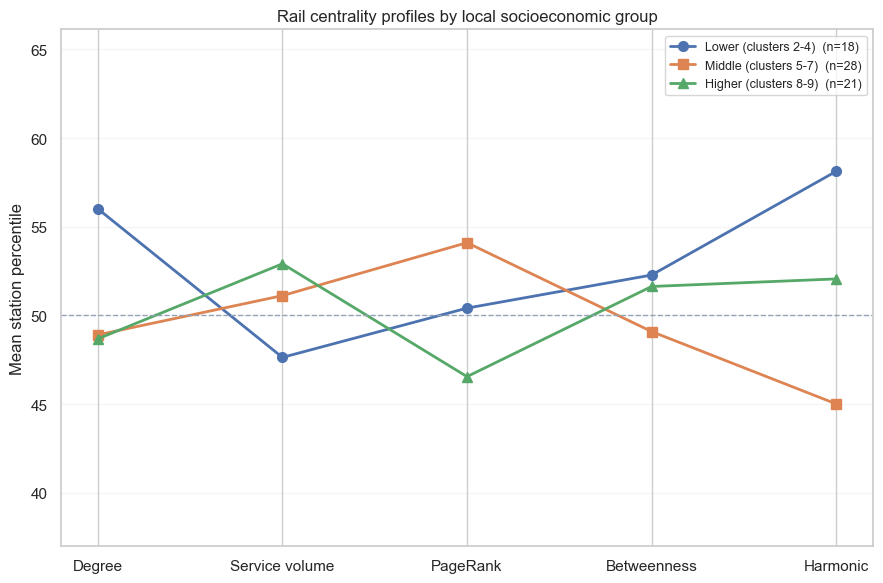

In [10]:
def group_summary(frame):
    summary = (
        frame.groupby("socio_group", observed=True)
        .agg(
            stations=("stop_id", "size"),
            within_polygon_share=("socio_join_method", lambda v: (v == "within").mean()),
            median_socio_cluster=("socio_cluster", "median"),
            mean_degree=("degree", "mean"),
            median_weighted_degree=("weighted_degree", "median"),
            mean_scheduled_stop_calls=("scheduled_stop_calls", "mean"),
            median_scheduled_stop_calls=("scheduled_stop_calls", "median"),
            total_scheduled_stop_calls=("scheduled_stop_calls", "sum"),
            mean_pagerank=("pagerank", "mean"),
            mean_betweenness=("betweenness", "mean"),
            median_betweenness=("betweenness", "median"),
            mean_harmonic=("harmonic", "mean"),
            articulation_point_share=("is_articulation_point", "mean"),
            stations_causing_fragmentation=(DAMAGE_METRIC, lambda v: (v > 0).sum()),
            mean_single_station_damage=(DAMAGE_METRIC, "mean"),
        )
        .reset_index()
    )
    summary["scheduled_stop_call_share"] = (
        summary["total_scheduled_stop_calls"] / summary["total_scheduled_stop_calls"].sum()
    )
    return summary


def plot_socioeconomic_profiles(frame, path):
    columns = [f"{m}_percentile" for m in CENTRALITY_METRICS]
    profile = frame.groupby("socio_group", observed=True)[columns].mean().T
    profile.index = [PROFILE_LABELS[m] for m in CENTRALITY_METRICS]
    counts = frame["socio_group"].value_counts()

    fig, axis = plt.subplots(figsize=(9, 6))
    for marker, group in zip(["o", "s", "^"], profile.columns):
        axis.plot(
            profile.index,
            100 * profile[group],
            marker=marker,
            linewidth=2,
            markersize=7,
            label=f"{group}  (n={int(counts[group])})",
        )
    axis.axhline(50, color="#94a3b8", ls="--", lw=1)
    axis.set_ylabel("Mean station percentile")
    axis.set_title("Rail centrality profiles by local socioeconomic group")
    low = float((100 * profile.values).min())
    high = float((100 * profile.values).max())
    axis.set_ylim(min(low, 50) - 8, max(high, 50) + 8)
    axis.grid(axis="y", alpha=0.2)
    axis.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(path, dpi=FIG_DPI)
    return fig


socioeconomic_groups = group_summary(frame)
display_cols = [
    "socio_group", "stations", "within_polygon_share", "mean_degree",
    "mean_scheduled_stop_calls", "mean_betweenness", "articulation_point_share",
    "stations_causing_fragmentation", "scheduled_stop_call_share",
]
print(socioeconomic_groups[display_cols].round(3).to_string(index=False))

fig = plot_socioeconomic_profiles(
    frame, STAGE / "figures" / "socioeconomic_centrality_profiles.png"
)
plt.show()

## District comparison - with sample sizes on the chart (fix 4)

The same comparison across the four administrative districts used throughout the project (Center / North / South / Jerusalem). Two panels: mean scheduled stop calls per station (service intensity) and the share of a district's stations that are cut vertices (structural fragility).

**The sample sizes matter more than the bars themselves.** The Center has 39 stations, the North 18, the South 7 and Jerusalem 3. A "cut-vertex share" computed over 3 stations moves in jumps of 33 percentage points - a single station changes the bar completely. So we mark n on every bar and flag the small groups, rather than inviting the reader to compare heights as if they were equally precise.

 region  stations  mean_socio_cluster  mean_scheduled_stop_calls  total_scheduled_stop_calls  mean_betweenness  mean_harmonic  articulation_point_share  mean_single_station_damage
   מרכז        39               6.410                    237.538                        9264             0.090          0.263                     0.128                       1.667
   צפון        18               5.833                    215.611                        3881             0.060          0.241                     0.389                       2.056
   דרום         7               4.571                    139.714                         978             0.023          0.209                     0.143                       0.286
ירושלים         3               4.667                    159.333                         478             0.010          0.238                     0.333                       0.333


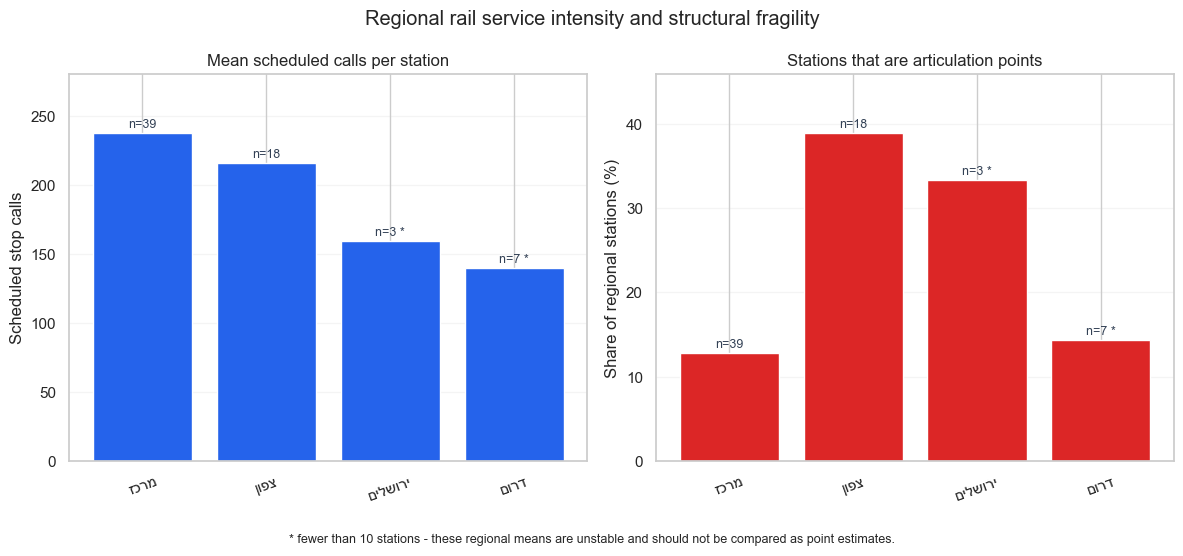

In [11]:
def regional_summary(frame):
    summary = (
        frame.groupby("region", dropna=False)
        .agg(
            stations=("stop_id", "size"),
            mean_socio_cluster=("socio_cluster", "mean"),
            mean_scheduled_stop_calls=("scheduled_stop_calls", "mean"),
            total_scheduled_stop_calls=("scheduled_stop_calls", "sum"),
            mean_betweenness=("betweenness", "mean"),
            mean_harmonic=("harmonic", "mean"),
            articulation_point_share=("is_articulation_point", "mean"),
            mean_single_station_damage=(DAMAGE_METRIC, "mean"),
        )
        .reset_index()
    )
    return summary.sort_values("mean_betweenness", ascending=False)


def plot_regional_profile(summary, path, small_group_threshold=10):
    ordered = summary.sort_values("mean_scheduled_stop_calls", ascending=False)
    labels = list(ordered["region"])
    counts = list(ordered["stations"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    panels = [
        (ordered["mean_scheduled_stop_calls"], "#2563eb",
         "Mean scheduled calls per station", "Scheduled stop calls"),
        (100 * ordered["articulation_point_share"], "#dc2626",
         "Stations that are articulation points", "Share of regional stations (%)"),
    ]
    for axis, (values, colour, title, ylabel) in zip(axes, panels):
        bars = axis.bar(labels, values, color=colour)
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.tick_params(axis="x", rotation=20)
        axis.grid(axis="y", alpha=0.2)
        axis.margins(y=0.18)
        # (fix 4) n on every bar; small groups flagged explicitly.
        for bar, n in zip(bars, counts):
            note = f"n={n}" + (" *" if n < small_group_threshold else "")
            axis.annotate(
                note,
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                fontsize=9,
                color="#334155",
            )
    fig.suptitle("Regional rail service intensity and structural fragility")
    fig.text(
        0.5,
        0.01,
        f"* fewer than {small_group_threshold} stations - these regional means are unstable "
        "and should not be compared as point estimates.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    fig.savefig(path, dpi=FIG_DPI)
    return fig


regions = regional_summary(frame)
print(regions.round(3).to_string(index=False))

fig = plot_regional_profile(regions, STAGE / "figures" / "regional_rail_profile.png")
plt.show()

## Formal test: is centrality related to socioeconomic status? (fix 3)

We run Spearman rank correlations between two socioeconomic variables (`socio_cluster`, the CBS band 1-10, and `socio_index_value`, the continuous index) and six network metrics, on two samples (all 67 stations, and the 44 stations matched clearly inside a statistical-area polygon). That's 2 x 6 x 2 = **24 hypothesis tests on the same 67 stations**.

Running 24 tests at alpha = 0.05 gives about a 70% chance of getting at least one "significant" result under a true null, so a raw p-value here means very little. We add two standard corrections:

- **Benjamini-Hochberg** (`q_value_bh`) controlling the false discovery rate;
- **Holm-Bonferroni** (`p_value_holm`) controlling the family-wise error rate.

Both are implemented directly inside the cell in a few lines, so the notebook stays low on dependencies. The tests also aren't independent - the six metrics are strongly correlated with each other (see the redundancy matrix) and the two samples overlap - so the corrections are conservative in one direction, and the effective number of independent tests is far below 24. None of this changes the conclusion, as the output shows.

In [12]:
def benjamini_hochberg(p_values):
    """BH false-discovery-rate adjusted p-values (q-values)."""
    p = np.asarray(p_values, dtype=float)
    n = p.size
    order = np.argsort(p)
    scaled = p[order] * n / np.arange(1, n + 1)
    monotone = np.minimum.accumulate(scaled[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(monotone, 0, 1)
    return out


def holm_bonferroni(p_values):
    """Holm-Bonferroni family-wise-error adjusted p-values."""
    p = np.asarray(p_values, dtype=float)
    n = p.size
    order = np.argsort(p)
    scaled = p[order] * (n - np.arange(n))
    monotone = np.maximum.accumulate(scaled)
    out = np.empty(n)
    out[order] = np.clip(monotone, 0, 1)
    return out


def correlation_table(frame):
    rows = []
    samples = {
        "all assignments": frame,
        "within-polygon only": frame[frame["socio_join_method"] == "within"],
    }
    for sample_name, sample in samples.items():
        for socio_variable in ["socio_cluster", "socio_index_value"]:
            for metric in PROFILE_METRICS:
                subset = sample[[socio_variable, metric]].dropna()
                rho, p_value = spearmanr(subset[socio_variable], subset[metric])
                rows.append(
                    {
                        "sample": sample_name,
                        "socioeconomic_variable": socio_variable,
                        "network_metric": metric,
                        "spearman_rho": float(rho),
                        "p_value_two_sided": float(p_value),
                        "n_stations": len(subset),
                    }
                )
    table = pd.DataFrame(rows)
    table["q_value_bh"] = benjamini_hochberg(table["p_value_two_sided"])
    table["p_value_holm"] = holm_bonferroni(table["p_value_two_sided"])
    table["significant_after_correction"] = table["q_value_bh"] < 0.05
    return table


correlations = correlation_table(frame)
print(
    correlations.round(4).to_string(index=False)
)

strongest = correlations.loc[correlations["spearman_rho"].abs().idxmax()]
smallest_p = correlations.loc[correlations["p_value_two_sided"].idxmin()]
print("\n--- honest summary of the 24 tests ---")
print(f"tests run: {len(correlations)}")
print(f"raw p < 0.05: {(correlations['p_value_two_sided'] < 0.05).sum()}")
print(f"BH q < 0.05: {(correlations['q_value_bh'] < 0.05).sum()}")
print(f"Holm p < 0.05: {(correlations['p_value_holm'] < 0.05).sum()}")
print(
    f"largest |rho|: {strongest.spearman_rho:+.3f} "
    f"({strongest.network_metric}, {strongest.socioeconomic_variable}, {strongest['sample']}, "
    f"raw p={strongest.p_value_two_sided:.3f})"
)
print(
    f"smallest raw p: {smallest_p.p_value_two_sided:.3f} "
    f"({smallest_p.network_metric}, {smallest_p['sample']}) -> "
    f"BH q={smallest_p.q_value_bh:.3f}"
)
print(
    "Interpretation: with n=67 (44 within-polygon) even a moderate true effect of |rho| ~ 0.24 "
    "would be needed for raw significance, so this is an underpowered null result, not evidence "
    "of exact equality."
)

             sample socioeconomic_variable                     network_metric  spearman_rho  p_value_two_sided  n_stations  q_value_bh  p_value_holm  significant_after_correction
    all assignments          socio_cluster                             degree       -0.1266             0.3075          67         NaN           1.0                         False
    all assignments          socio_cluster                    weighted_degree        0.0752             0.5453          67         NaN           1.0                         False
    all assignments          socio_cluster                           pagerank       -0.0544             0.6618          67         NaN           1.0                         False
    all assignments          socio_cluster                        betweenness       -0.0237             0.8488          67         NaN           1.0                         False
    all assignments          socio_cluster                           harmonic       -0.0892             0

## Saving the stage outputs

Everything written here is saved to this notebook's dedicated stage folder, `outputs/nb/12_rail_socioeconomic/`. The station-level table is sorted by the family-balanced composite and keeps *both* composite scores and *both* definitions of the damage percentile, so a reader can reconstruct either convention without rerunning the notebook. The CSV files are written in `utf-8-sig` encoding so Hebrew station names open correctly in Excel.

In [13]:
tables_dir = STAGE / "tables"

frame.sort_values("composite_centrality_score_balanced", ascending=False).to_csv(
    tables_dir / "rail_station_archetypes.csv", index=False, encoding="utf-8-sig"
)
correlations.to_csv(
    tables_dir / "rail_socioeconomic_correlations.csv", index=False, encoding="utf-8-sig"
)
redundancy.to_csv(tables_dir / "rail_centrality_spearman.csv", encoding="utf-8-sig")
composite_comparison.sort_values("rank_balanced").to_csv(
    tables_dir / "composite_score_comparison.csv", index=False, encoding="utf-8-sig"
)
socioeconomic_groups.to_csv(
    tables_dir / "rail_socioeconomic_group_summary.csv", index=False, encoding="utf-8-sig"
)
regions.to_csv(
    tables_dir / "rail_regional_summary.csv", index=False, encoding="utf-8-sig"
)

for path in sorted(STAGE.rglob("*")):
    if path.is_file():
        print(path.relative_to(OUT), f"({path.stat().st_size / 1024:.1f} KB)")

12_rail_socioeconomic\figures\centrality_profile_heatmap.png (329.3 KB)
12_rail_socioeconomic\figures\regional_rail_profile.png (109.1 KB)
12_rail_socioeconomic\figures\service_vs_structural_damage.png (160.5 KB)
12_rail_socioeconomic\figures\socioeconomic_centrality_profiles.png (132.1 KB)
12_rail_socioeconomic\tables\composite_score_comparison.csv (4.6 KB)
12_rail_socioeconomic\tables\rail_centrality_spearman.csv (1.0 KB)
12_rail_socioeconomic\tables\rail_regional_summary.csv (0.7 KB)
12_rail_socioeconomic\tables\rail_socioeconomic_correlations.csv (2.1 KB)
12_rail_socioeconomic\tables\rail_socioeconomic_group_summary.csv (1.0 KB)
12_rail_socioeconomic\tables\rail_station_archetypes.csv (28.1 KB)


## Conclusions

**1. The central finding is a negative one, and we report it as such.** Across 24 Spearman tests (two socioeconomic variables x six network metrics x two join samples) nothing reaches significance even *before* correction for multiple comparisons; the strongest relationship is about |rho| ~ 0.27 and the smallest raw p-value is ~0.08, which becomes a BH q-value well above 0.05. In this dataset **there's no detectable systematic relationship between a rail station's centrality and the socioeconomic cluster of its statistical area.** With 67 stations (44 of them matched clearly inside a polygon) the study has low statistical power: only effects on the order of |rho| > 0.24 would have been detectable. So the correct phrasing is "no evidence of a relationship at this sample size", not "proof of equity".

**2. The weak signals that do exist all point the same way, and they're worth noting descriptively.** Every correlation between the cluster and degree, harmonic reach and single-failure damage is *negative*, meaning that if anything, stations in lower-cluster areas sit in slightly better-connected and slightly more fragile positions - the opposite of the naive expectation. The one consistently positive metric is weighted degree (service volume), which is dominated by the Tel Aviv core.

**3. Service volume isn't the same as structural criticality.** Figure 2 separates two distinct failure modes: busy hubs the network can route around ("redundant high-service hub") versus quiet branch gateways whose loss disconnects a whole branch. Only 7 stations are *critical high-service hubs* (busy **and** a damaging cut vertex); another 6 are low-traffic branch gateways that a traffic-based priority list would miss entirely. This is the operationally useful finding of this notebook.

**4. Composite scores are fragile by construction.** Because `weighted_degree`, `pagerank` and `scheduled_stop_calls` are near-duplicates (rho up to 0.94), the plain average of five metrics quietly weights service volume 3:1:1 against brokerage and reach. The family-balanced score is still highly rank-correlated with the original, but individual stations move several places in the ranking. Any "importance ranking" of this kind should be read as one defensible order out of several, not the only one.

**5. Two data caveats limit how far any equity claim can be taken.** About a third of the rail stations (23 of 67) had to be matched to the *nearest* statistical area rather than a containing one, because stations are often built at the edge of the built-up area - so their socioeconomic label is noisy. And the district breakdown rests on very small groups (Jerusalem n = 3, South n = 7), so those bars carry an explicit n and a warning rather than being compared as point estimates.